In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [6]:
# Load dataset
df = pd.read_csv("size_trials4.csv", header=None)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print(X_scaled.shape)

# Apply PCA over all components to find contribution
pca = PCA(n_components=56)
pca.fit(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Print contribution of each principal component
for i, ratio in enumerate(explained_variance_ratio):
   print(f"Principal Component {i+1}: {ratio:.4f} ({ratio*100:.2f}% of total variance)")

FileNotFoundError: [Errno 2] No such file or directory: 'size_trials4.csv'

In [3]:
# Reduce dimensions to 3D using PCA - accounts for > 60% of variance
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

NameError: name 'X_scaled' is not defined

### K means after PCA in 3D

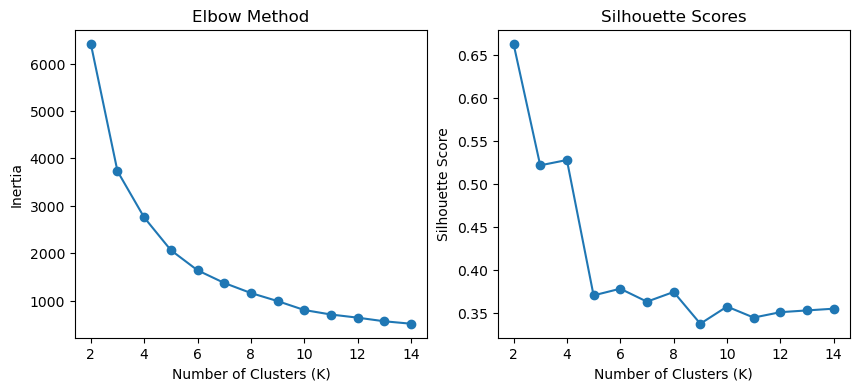

In [5]:
# Find optimal K using the Elbow Method
inertia = []
silhouette_scores = []
K_range = range(2, 15)  # Test clusters from 2 to 14

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.show()

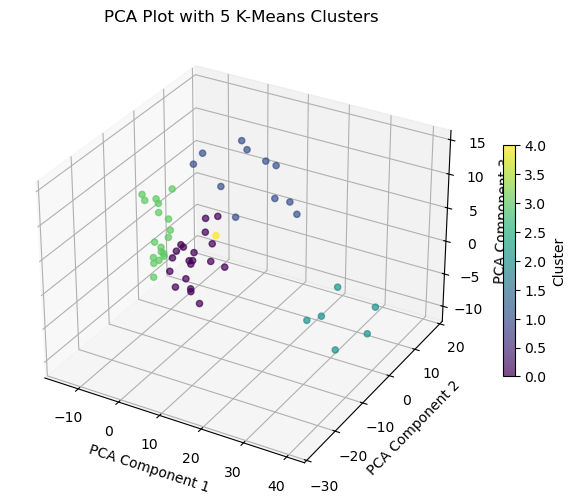

In [6]:
# Apply K-Means clustering on the PCA results
optimal_k = 5  # Choose the optimal number of clusters (could be determined using the elbow method)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_pca)

# Plot PCA results with clusters in 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot in 3D
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df['Cluster'], cmap='viridis', alpha=0.7)

# Add labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title(f"PCA Plot with {optimal_k} K-Means Clusters")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()


### PCA Component Reduction Labeled by Size in 3D

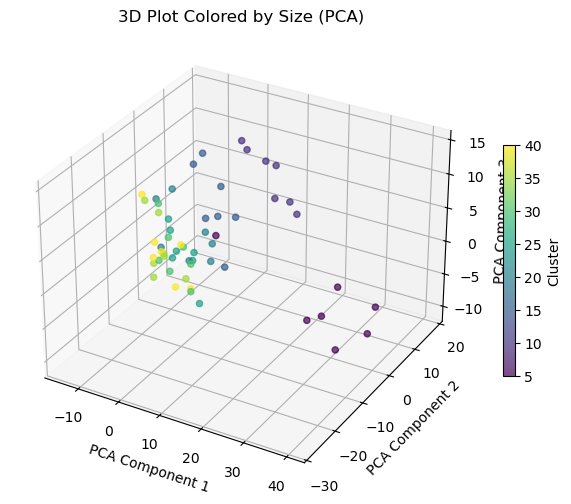

In [7]:
# 3D Plot of clusters colored by size
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

Sz = []
for i in range(56):
    Sz.append(((i%8)*5)+5)

df['Size'] = Sz

# Scatter plot (invisible, to maintain scale on axes)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df['Size'], cmap='viridis', alpha=0.7, zorder=1, depthshade=False)

# Labels and titled
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D Plot Colored by Size (PCA)")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()

### K means after PCA in 2D

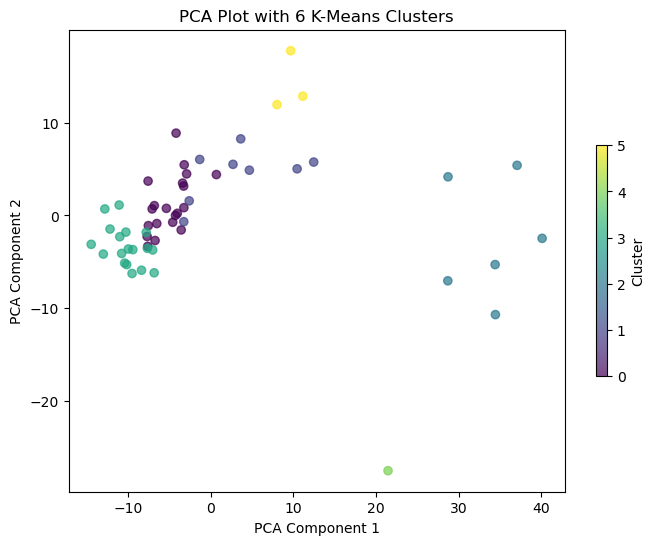

In [8]:
# Apply K-Means clustering on the PCA results
optimal_k = 6  # Choose the optimal number of clusters (could be determined using the elbow method)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_pca)

# Plot PCA results with clusters
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.7)

# Add labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title(f"PCA Plot with {optimal_k} K-Means Clusters")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()


### PCA Component Reduction Labeled by Size in 2D

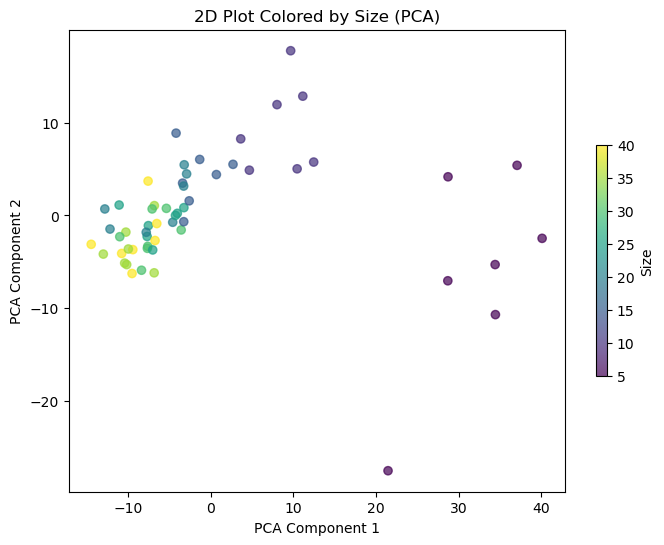

In [10]:
# 2D Plot of clusters colored by size
fig, ax = plt.subplots(figsize=(8, 6))

Sz = []
for i in range(56):
    Sz.append(((i % 8) * 5) + 5)

df['Size'] = Sz

# Scatter plot (invisible, to maintain scale on axes)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Size'], cmap='viridis', alpha=0.7, zorder=1)

# Labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("2D Plot Colored by Size (PCA)")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Size")

plt.show()